Propagating MOLNIYA for 30 days...

  MOLNIYA RESULTS AFTER 30 DAYS (Inc = 63.4°)
Initial Arg. of Perigee: 270.000 deg
Final Arg. of Perigee:   270.009 deg
Delta ω:               0.00928 deg
--> FROZEN EFFECT: The line of apsides is locked

Generating 3D plot...


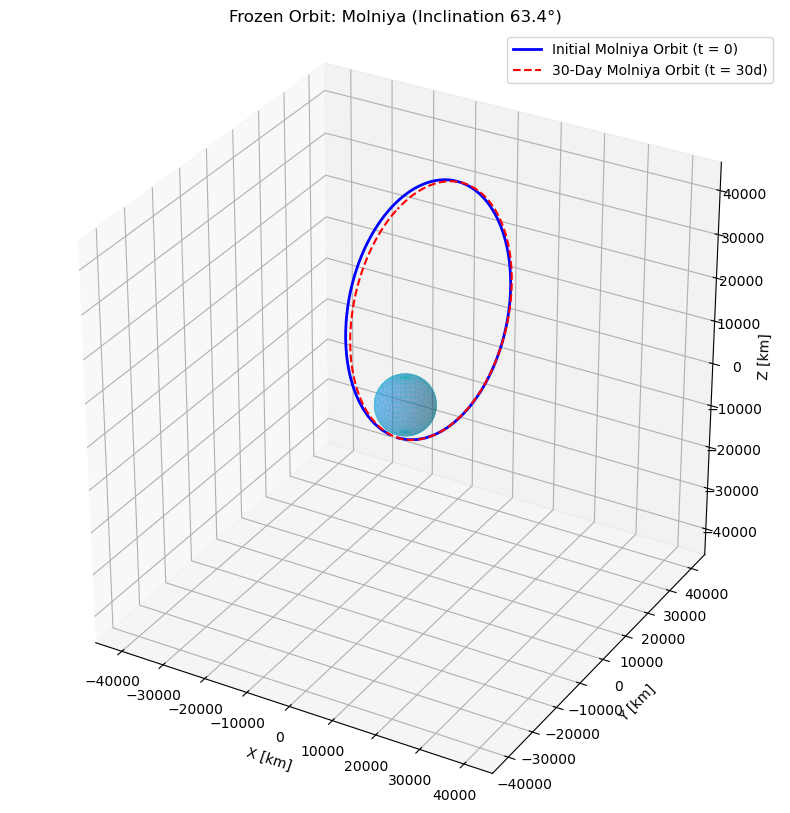

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel

# ==========================================
# 2. TIME AND FRAMES DEFINITION
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. MOLNIYA ORBIT CREATION (Critical Inclination)
# ==========================================
# 12-hour period (~43200 seconds), yields a semi-major axis of ~26562 km
a = 26562000.0  
e = 0.74        # Highly elliptical (low perigee, extremely high apogee above 39000 km)
i = math.radians(63.4349)  # CRITICAL INCLINATION
omega = math.radians(270.0) # Perigee at South, Apogee at North
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 1000.0)

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 500.0
tolerances = NumericalPropagator.tolerances(10.0, initial_orbit, initial_orbit.getType())
integrator = DormandPrince853Integrator(min_step, max_step, JArray_double.cast_(tolerances[0]), JArray_double.cast_(tolerances[1]))
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# Using J2 Gravity (4x4) to isolate the freezing effect
gravity_provider = GravityFieldFactory.getNormalizedProvider(4, 4)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# ==========================================
# 5. PROPAGATION (30 DAYS)
# ==========================================
days = 30.0
duration = days * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagating MOLNIYA for {int(days)} days...")
final_state = propagator.propagate(final_date)

orbit_30d = KeplerianOrbit(final_state.getOrbit())
omega_fin = math.degrees(orbit_30d.getPerigeeArgument()) % 360.0

print("\n========================================================")
print(f"  MOLNIYA RESULTS AFTER {int(days)} DAYS (Inc = 63.4°)")
print("========================================================")
print(f"Initial Arg. of Perigee: {math.degrees(omega):.3f} deg")
print(f"Final Arg. of Perigee:   {omega_fin:.3f} deg")
print(f"Delta \u03C9:               {omega_fin - math.degrees(omega):.5f} deg")
print("--> FROZEN EFFECT: The line of apsides is locked")
print("========================================================\n")

# ==========================================
# 6. 3D VISUALIZATION
# ==========================================
print("Generating 3D plot...")
ephemeris = ephemeris_generator.getGeneratedEphemeris()
orbital_period = 43200.0  # 12 hours

def extract_orbit(start_time, end_time):
    times = np.linspace(start_time, end_time, 200)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = extract_orbit(0, orbital_period)                                   
x30, y30, z30 = extract_orbit(duration - orbital_period, duration)              

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.0, label='Initial Molniya Orbit (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=1.5, linestyle='dashed', label='30-Day Molniya Orbit (t = 30d)')

# Expanded view to fit the apogee
lim = R_E_km + 40000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Frozen Orbit: Molniya (Inclination 63.4°)')
ax.legend(loc='upper right')

plt.show()